## 01_intro

In [2]:
import os

# 1. 定义本地存放数据的根目录 (保存在当前Notebook同级目录下)
base_path = './ibm-telco-churn'
csv_file_path = f'{base_path}/Telco-Customer-Churn.csv' 
bronze_tbl_path = f'{base_path}/bronze/'
silver_tbl_path = f'{base_path}/silver/'

# 替换掉原本复杂的用户名逻辑，直接指定一个数据库名称
database_name = 'dm_ibm_telco_churn_local'
bronze_tbl_name = 'bronze_customers'
silver_tbl_name = 'silver_monthly_customers'

# 2. 在服务器上实际创建这个文件夹，准备接收下载的文件
os.makedirs(base_path, exist_ok=True)

print(f"✅ 路径配置完成！")
print(f"数据即将下载至: {csv_file_path}")

✅ 路径配置完成！
数据即将下载至: ./ibm-telco-churn/Telco-Customer-Churn.csv


In [3]:
!wget -O ./ibm-telco-churn/Telco-Customer-Churn.csv https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

--2026-04-12 20:55:13--  https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 970457 (948K) [text/plain]
Saving to: ‘./ibm-telco-churn/Telco-Customer-Churn.csv’

./ibm-telco-churn/T 100%[===================>] 947.71K  1.44MB/s    in 0.6s    

2026-04-12 20:55:14 (1.44 MB/s) - ‘./ibm-telco-churn/Telco-Customer-Churn.csv’ saved [970457/970457]



In [4]:
# Load libraries
import shutil
import os # 引入 os 库
from pyspark.sql.functions import col, when
from pyspark.sql.types import StructType, StructField, DoubleType, StringType, IntegerType

# --- 修改部分开始 ---

# 1. 移除 dbutils，直接指定本地用户名（当前为 root）
user = "root" 
username_sql = user.replace(".", "_")
database_name = f'dm_ibm_telco_churn_{username_sql}'

# 2. 将数据主路径修改为你当前 Jupyter 服务器上的相对路径
data_path = './ibm-telco-churn'

# 3. 重新定义文件和表格的路径 (指向本地而非云端 DBFS)
# 注意：为了不影响你运行教程后面的代码，这里我保留了原来的变量名 driver_to_dbfs_path
driver_to_dbfs_path = f'{data_path}/Telco-Customer-Churn.csv' 
bronze_tbl_path = f'{data_path}/bronze/'
silver_tbl_path = f'{data_path}/silver/'

# --- 修改部分结束 ---

bronze_tbl_name = 'bronze_customers'
silver_tbl_name = 'silver_monthly_customers'

# 打印一下核心路径，确保配置正确
print("✅ 环境配置完成！")
print(f"使用的数据库名: {database_name}")
print(f"CSV 数据文件路径: {driver_to_dbfs_path}")
print(f"Bronze 表格路径: {bronze_tbl_path}")

✅ 环境配置完成！
使用的数据库名: dm_ibm_telco_churn_root
CSV 数据文件路径: ./ibm-telco-churn/Telco-Customer-Churn.csv
Bronze 表格路径: ./ibm-telco-churn/bronze/


In [9]:
# Define schema
schema = StructType([
  StructField('customerID', StringType()),
  StructField('gender', StringType()),
  StructField('seniorCitizen', DoubleType()),
  StructField('partner', StringType()),
  StructField('dependents', StringType()),
  StructField('tenure', DoubleType()),
  StructField('phoneService', StringType()),
  StructField('multipleLines', StringType()),
  StructField('internetService', StringType()), 
  StructField('onlineSecurity', StringType()),
  StructField('onlineBackup', StringType()),
  StructField('deviceProtection', StringType()),
  StructField('techSupport', StringType()),
  StructField('streamingTV', StringType()),
  StructField('streamingMovies', StringType()),
  StructField('contract', StringType()),
  StructField('paperlessBilling', StringType()),
  StructField('paymentMethod', StringType()),
  StructField('monthlyCharges', DoubleType()),
  StructField('totalCharges', DoubleType()),
  StructField('churnString', StringType())
  ])

In [16]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("TelcoChurnLocal") \
    .getOrCreate()

# Load data
bronze_df = spark.read.format('csv').schema(schema).option('header','true').load(driver_to_dbfs_path)

bronze_df.show(5)

bronze_df.printSchema()

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----------+
|customerID|gender|seniorCitizen|partner|dependents|tenure|phoneService|   multipleLines|internetService|onlineSecurity|onlineBackup|deviceProtection|techSupport|streamingTV|streamingMovies|      contract|paperlessBilling|       paymentMethod|monthlyCharges|totalCharges|churnString|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----------+
|7590-VHVEG|Female|          0.0|    Yes|        No|   1.0|          No|No phone service|            DSL|            No|         Yes|              N

26/04/12 21:09:33 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn
 Schema: customerID, gender, seniorCitizen, partner, dependents, tenure, phoneService, multipleLines, internetService, onlineSecurity, onlineBackup, deviceProtection, techSupport, streamingTV, streamingMovies, contract, paperlessBilling, paymentMethod, monthlyCharges, totalCharges, churnString
Expected: churnString but found: Churn
CSV file: file:///data/Project1/ibm-telco-churn/Telco-Customer-Churn.csv


In [17]:
# Construct silver table
silver_df = bronze_df.withColumn('churn',when(col('churnString') == 'Yes',1).when(col('churnString') == 'No',0).otherwise('Unknown'))\
                     .drop('churnString').filter(col('contract') == 'Month-to-month')\
                     .filter(col('internetService') != 'No')

In [18]:
# Delete the old database and tables if needed

_ = spark.sql('DROP DATABASE IF EXISTS {} CASCADE'.format(database_name))

 

# Create database to house tables

_ = spark.sql('CREATE DATABASE {}'.format(database_name))

_ = spark.sql('USE {}'.format(database_name))

In [24]:
# Drop any old delta lake files if needed (e.g. re-running this notebook with the same bronze_tbl_path and silver_tbl_path)
shutil.rmtree('/dbfs'+bronze_tbl_path, ignore_errors=True)
shutil.rmtree('/dbfs'+silver_tbl_path, ignore_errors=True)

In [25]:
# Write out bronze-level data to Parquet (替换掉 delta)
_ = bronze_df.write.format('parquet').mode('overwrite').save(bronze_tbl_path)

# Write out silver-level data to Parquet (替换掉 delta)
# 注意：前提是你前面已经生成了 silver_df 这个变量
_ = silver_df.write.format('parquet').mode('overwrite').save(silver_tbl_path)

print("✅ 数据保存成功！")

26/04/12 21:34:58 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn
 Schema: customerID, gender, seniorCitizen, partner, dependents, tenure, phoneService, multipleLines, internetService, onlineSecurity, onlineBackup, deviceProtection, techSupport, streamingTV, streamingMovies, contract, paperlessBilling, paymentMethod, monthlyCharges, totalCharges, churnString
Expected: churnString but found: Churn
CSV file: file:///data/Project1/ibm-telco-churn/Telco-Customer-Churn.csv
26/04/12 21:34:59 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, O

✅ 数据保存成功！


In [30]:
import os

# 1. 获取绝对路径，防止 Spark SQL 找错地方
absolute_silver_path = os.path.abspath('./ibm-telco-churn/silver/')

print(f"确切的物理路径是: {absolute_silver_path}")

# 2. 补救措施：确保数据真的写进去了！
# (如果你确定上一步已经成功保存了数据，这两行可以注释掉；如果不确定，请去掉注释运行它)
# 注意：这需要你之前的代码中已经生成了 silver_df 这个变量
try:
    silver_df.write.format('parquet').mode('overwrite').save(absolute_silver_path)
    print("✅ 数据已确认保存至该路径。")
except NameError:
    print("⚠️ 提示：你的环境中还没有 silver_df 变量，请确保你按顺序运行了教程前面的代码。")

# 3. 再次建表，这次使用绝对路径
try:
    _ = spark.sql(f'''
      CREATE TABLE IF NOT EXISTS `{database_name}`.{silver_tbl_name}
      USING PARQUET 
      LOCATION '{absolute_silver_path}'
      ''')
    print(f"✅ 成功创建表格: {database_name}.{silver_tbl_name}")
except Exception as e:
    print(f"建表依然失败，错误信息：{e}")

确切的物理路径是: /data/Project1/ibm-telco-churn/silver
✅ 数据已确认保存至该路径。
✅ 成功创建表格: dm_ibm_telco_churn_root.silver_monthly_customers


26/04/12 21:49:57 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn
 Schema: customerID, gender, seniorCitizen, partner, dependents, tenure, phoneService, multipleLines, internetService, onlineSecurity, onlineBackup, deviceProtection, techSupport, streamingTV, streamingMovies, contract, paperlessBilling, paymentMethod, monthlyCharges, totalCharges, churnString
Expected: churnString but found: Churn
CSV file: file:///data/Project1/ibm-telco-churn/Telco-Customer-Churn.csv


In [29]:
# 1. 在本地环境中，先确保名为 database_name 的数据库已经存在
spark.sql("CREATE DATABASE IF NOT EXISTS {}".format(database_name))

# 2. Create silver table (注意：将 DELTA 修改为了 PARQUET)
_ = spark.sql('''
  CREATE TABLE IF NOT EXISTS `{}`.{}
  USING PARQUET 
  LOCATION '{}'
  '''.format(database_name, silver_tbl_name, silver_tbl_path))

# 打印提示，确认执行成功
print(f"✅ 成功创建表格: {database_name}.{silver_tbl_name}")

✅ 成功创建表格: dm_ibm_telco_churn_root.silver_monthly_customers


## 02_kaplan_meier

In [32]:
# Import libraries

import matplotlib.pyplot as plt

import pandas as pd

import numpy as np

# ! pip install lifelines

from lifelines import KaplanMeierFitter

from lifelines.utils import median_survival_times

from lifelines.statistics import pairwise_logrank_test

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 442.5 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.8 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 1.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 12.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 26.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.0/447.0 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 36.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4119 sha25

In [33]:
# Load the telco silver table
telco_pd = spark.table('silver_monthly_customers').toPandas()

In [34]:
kmf = KaplanMeierFitter()

T=telco_pd['tenure']

C=telco_pd['churn'].astype(float)

kmf.fit(T,C)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 3351 total observations, 1795 right-censored observations>

<Axes: title={'center': 'Kaplan-Meier Survival Curve: Population level'}, xlabel='timeline'>

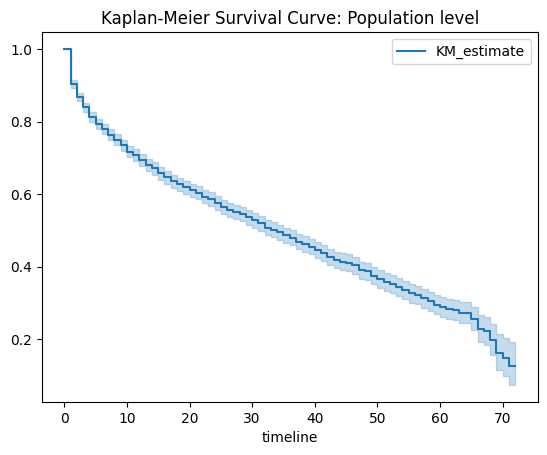

In [35]:
kmf.plot(title='Kaplan-Meier Survival Curve: Population level')

In [36]:
kmf.median_survival_time_

np.float64(34.0)

# Helper function for plotting Kaplan-Meier curves at the covariate level

def plot_km(col):

  ax = plt.subplot(111)

  for r in telco_pd[col].unique():

    ix = telco_pd[col] == r

    kmf.fit(T[ix], C[ix],label=r)

    kmf.plot(ax=ax)

    

# Helper function for printing out Log-rank test results

def print_logrank(col):

  log_rank = pairwise_logrank_test(telco_pd['tenure'], telco_pd[col], telco_pd['churn'])

  return log_rank.summary

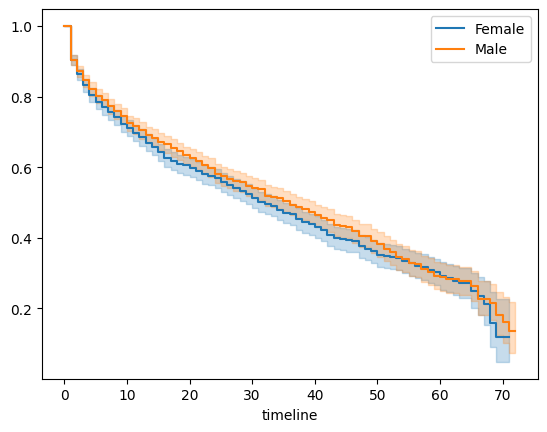

In [38]:
plot_km('gender')

In [39]:
print_logrank('gender')

,,test_statistic,p,-log2(p)
Female,Male,2.038938,0.153317,2.705414


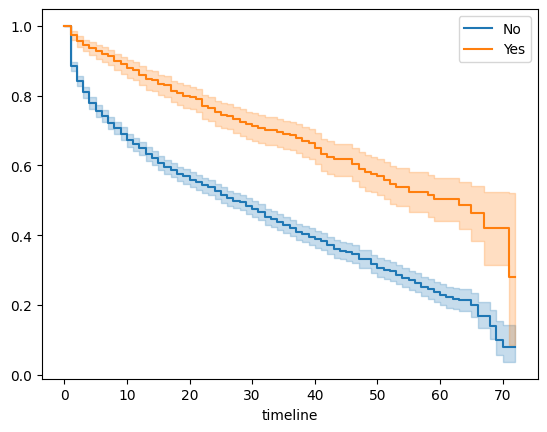

In [40]:
plot_km('onlineSecurity')

In [41]:
print_logrank('onlineSecurity')

,,test_statistic,p,-log2(p)
No,Yes,141.60316,1.187554e-32,106.053706


### ......

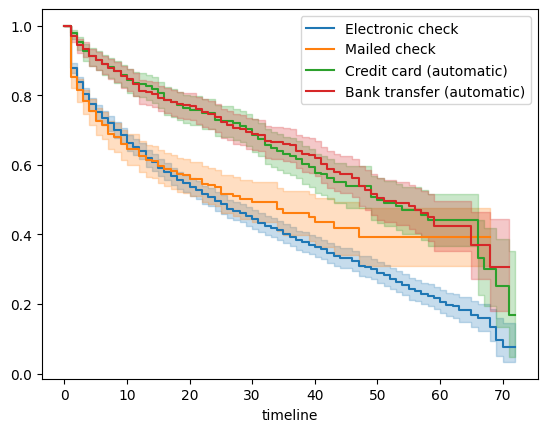

In [43]:
plot_km('paymentMethod')

In [44]:
print_logrank('paymentMethod')

test_statistic  \
Bank transfer (automatic) Credit card (automatic)        0.061543   
                          Electronic check              91.191889   
                          Mailed check                  43.536998   
Credit card (automatic)   Electronic check              79.991082   
                          Mailed check                  39.684613   
Electronic check          Mailed check                   0.898320   

                                                              p   -log2(p)  
Bank transfer (automatic) Credit card (automatic)  8.040732e-01   0.314601  
                          Electronic check         1.303937e-21  69.377616  
                          Mailed check             4.160192e-11  34.484559  
Credit card (automatic)   Electronic check         3.761035e-19  61.205504  
                          Mailed check             2.984678e-10  31.641706  
Electronic check          Mailed check             3.432326e-01   1.542741

In [45]:
def get_survival_probs(col,val):

  ix = telco_pd[col] == val

  return kmf.fit(T[ix],C[ix],label=val)  

In [46]:
# Extract survival probabilities for customers with internetService = DSL

sp_internet_dsl = get_survival_probs('internetService','DSL')

In [47]:
pd.DataFrame(sp_internet_dsl.survival_function_at_times(range(0,10)))

,DSL
0,1.000000
1,0.902698
2,0.864380
3,0.834702
4,0.810522
5,0.794352
6,0.783900
7,0.776362
8,0.768486
9,0.750833


## 03_cox_proportional_hazards

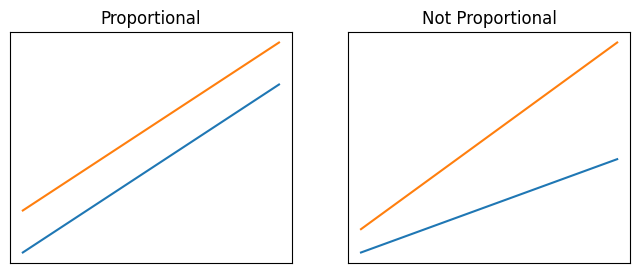

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(8,3))
 
ax1.plot([1,2,3,4,5],[1,2,3,4,5])
ax1.plot([1,2,3,4,5],[2,3,4,5,6])
ax1.title.set_text('Proportional')
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
 
ax2.plot([1,2,3,4,5],[1,2,3,4,5])
ax2.plot([1,2,3,4,5],[2,4,6,8,10])
ax2.title.set_text('Not Proportional')
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)

In [51]:
import pandas as pd
! pip install seaborn
import seaborn as sns
import numpy as np
 
from lifelines.fitters.coxph_fitter import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
from lifelines import KaplanMeierFitter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 845.5 kB/s eta 0:00:00a 0:00:01


In [52]:
# Encode columns of interest
encode_cols = ['dependents','internetService','onlineBackup','techSupport','paperlessBilling']
 
encoded_pd = pd.get_dummies(telco_pd,
               columns=encode_cols,
               prefix=encode_cols,
               drop_first=False)
 
encoded_pd.head()

,customerID,gender,seniorCitizen,partner,tenure,phoneService,multipleLines,onlineSecurity,deviceProtection,streamingTV,...,dependents_No,dependents_Yes,internetService_DSL,internetService_Fiber optic,onlineBackup_No,onlineBackup_Yes,techSupport_No,techSupport_Yes,paperlessBilling_No,paperlessBilling_Yes
0,7590-VHVEG,Female,0.0,Yes,1.0,No,No phone service,No,No,No,...,True,False,True,False,False,True,True,False,False,True
1,3668-QPYBK,Male,0.0,No,2.0,Yes,No,Yes,No,No,...,True,False,True,False,False,True,True,False,False,True
2,9237-HQITU,Female,0.0,No,2.0,Yes,No,No,No,No,...,True,False,False,True,True,False,True,False,False,True
3,9305-CDSKC,Female,0.0,No,8.0,Yes,Yes,No,Yes,Yes,...,True,False,False,True,True,False,True,False,False,True
4,1452-KIOVK,Male,0.0,No,22.0,Yes,Yes,No,No,Yes,...,False,True,False,True,False,True,True,False,False,True


In [53]:
# Create new dataframe consisting of only the variables needed to fit the model
survival_pd = encoded_pd[['churn','tenure','dependents_Yes','internetService_DSL','onlineBackup_Yes','techSupport_Yes']]

In [54]:
# Cast churn column as a float
survival_pd.loc[:,'churn'] = survival_pd.loc[:,'churn'].astype('float')

In [55]:
cph = CoxPHFitter(alpha=0.05)
cph.fit(survival_pd, 'tenure', 'churn')

<lifelines.CoxPHFitter: fitted with 3351 total observations, 1795 right-censored observations>

In [56]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 3351 total observations, 1795 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 3351
number of events observed = 1556
   partial log-likelihood = -11315.95
         time fit was run = 2026-04-13 03:49:29 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
dependents_Yes      -0.33      0.72      0.07           -0.47           -0.19                0.63                0.83
internetService_DSL -0.22      0.80      0.06           -0.33           -0.10                0.72                0.90
onlineBackup_Yes    -0.78      0.46      0.06           -0.89           -0.66                0.41                0.52
techSupport_Yes     -0.64      0.53      0.08           -0.79           -0.49                0.46                0.61

                     cmp to      z      p  -log2(p)
covariate                                          
dependents_Yes         0.00  -4.64 <0.005     18.12
internetService_DSL    0.00  -3.68 <0.005     12.07
onlineBackup_Yes       0.00 -13.13 <0.005    128.37
techSupport_Yes        0.00  -8.48 <0.005     55.36
---
Concordance = 0.64
Partial AIC = 22639.90
log-likelihood ratio test = 337.77 on 4 df
-log2(p) of ll-ratio test = 236.24

<Axes: xlabel='HR (95% CI)'>

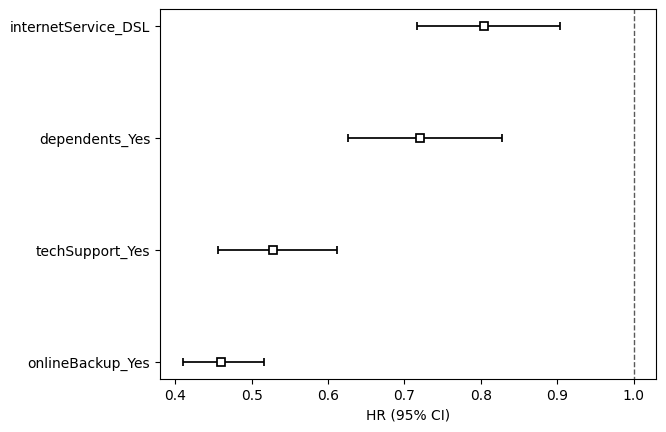

In [57]:
cph.plot(hazard_ratios=True)

In [58]:
cph.check_assumptions(survival_pd,p_value_threshold=0.05)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'internetService_DSL' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['internetService_DSL', ...]`
in the call in `.fit`. See documentation in link [E] below.

2. Variable 'onlineBackup_Yes' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['onlineBackup_Yes', ...]` in
the call in `.fit`. See documentation in link [E] below.

3. Variable 'techSupport_Yes' failed the non-proportional test: p-value is 0.0002.

   Advice: with so few unique values (only 2), you can include `strata=['techSupport_Yes', ...]` in
the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://l

[]


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'internetService_DSL' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['internetService_DSL', ...]`
in the call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


2. Variable 'onlineBackup_Yes' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['onlineBackup_Yes', ...]` in
the call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


3. Variable 'techSupport_Yes' failed the non-proportional test: p-value is 0.0002.

   Advice: with so few unique values (only 2), you can include `strata=['techSupport_Yes', ...]` in
the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/lat

[[<Axes: xlabel='rank-transformed time\n(p=0.3680)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2232)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0002)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0044)'>]]

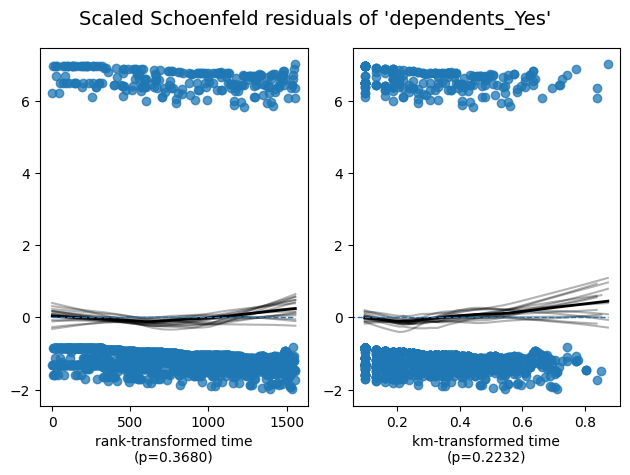

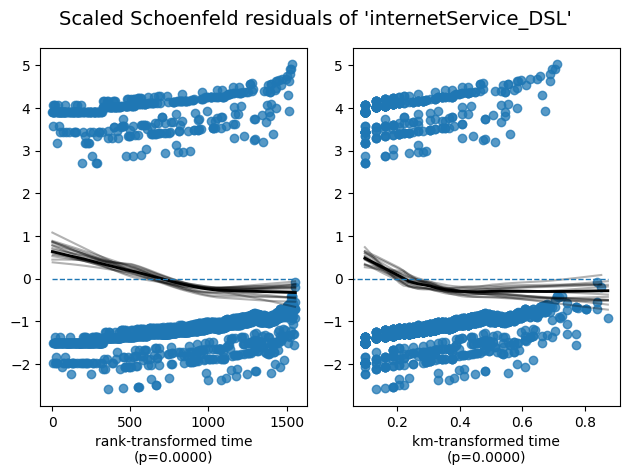

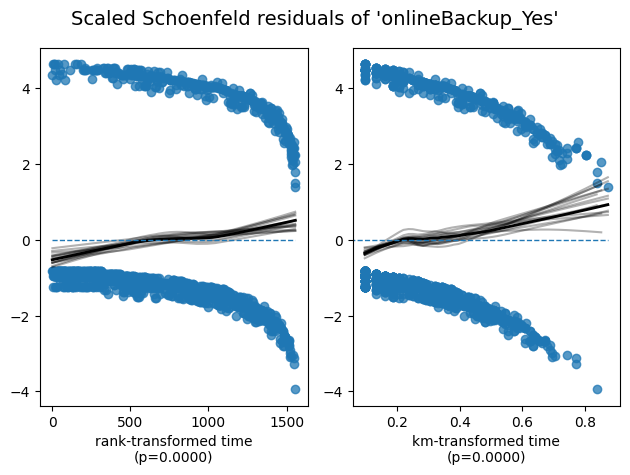

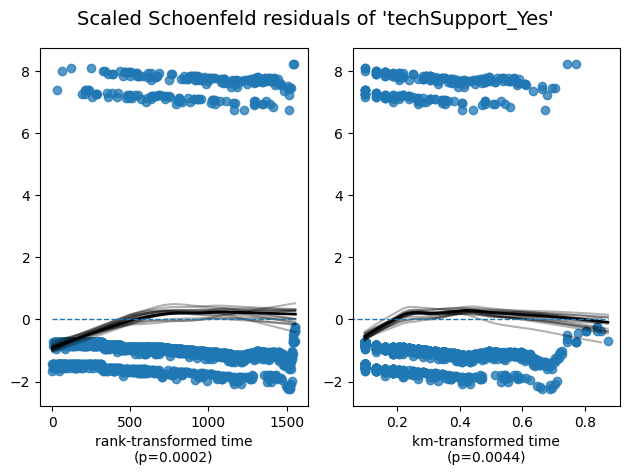

In [59]:
cph.check_assumptions(survival_pd,p_value_threshold=0.05,show_plots=True)

In [60]:
# Fit the Kaplan-Meier model
kmf = KaplanMeierFitter()
 
T=telco_pd['tenure'] #duration
C=telco_pd['churn'].astype(float) #event observed
 
kmf.fit(T,C)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 3351 total observations, 1795 right-censored observations>

In [61]:
# Utility function for plotting
import matplotlib.pyplot as plt
def plot_km_loglog(col):
  ax = plt.subplot(111)
  for r in telco_pd[col].unique():
    ix = telco_pd[col] == r
    kmf.fit(T[ix], C[ix],label=r)
    kmf.plot_loglogs(ax=ax)

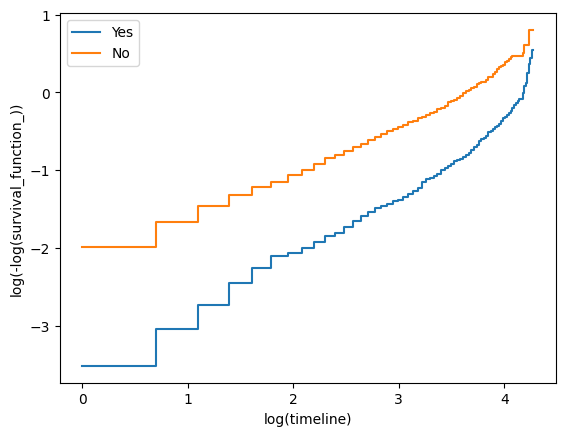

In [62]:
plot_km_loglog('onlineBackup')

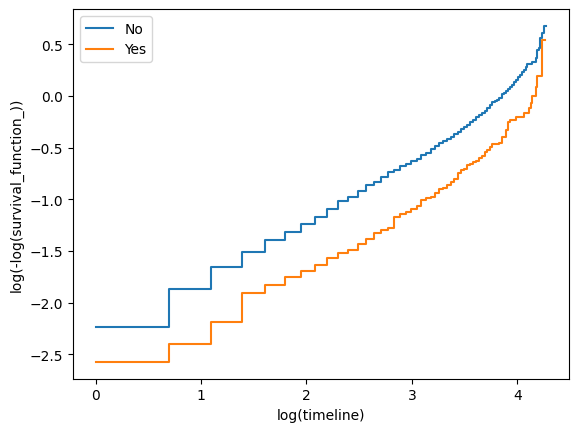

In [63]:
plot_km_loglog('dependents')

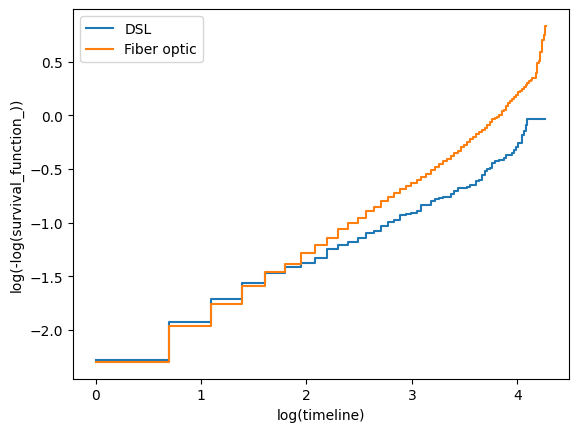

In [64]:
plot_km_loglog('internetService')

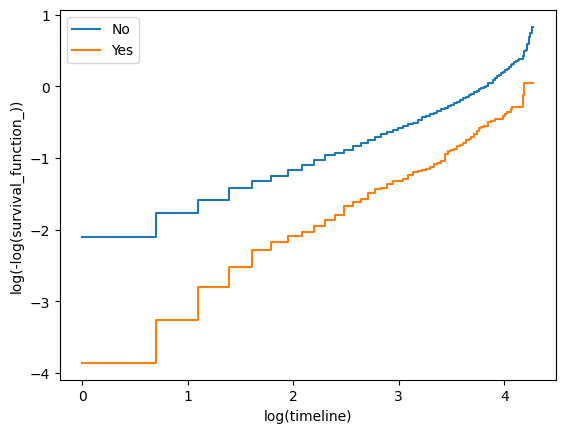

In [65]:
plot_km_loglog('techSupport')

## 04_accelerated_failure_time

In [70]:
# Import libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
 
from lifelines import WeibullAFTFitter,LogNormalAFTFitter,LogLogisticAFTFitter
from lifelines.fitters.coxph_fitter import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

In [66]:
# Load the telco silver table
telco_pd = spark.table('silver_monthly_customers').toPandas()

In [67]:
encode_cols = ['partner','multipleLines','internetService','onlineSecurity', 'onlineBackup','deviceProtection','techSupport','paymentMethod']
 
encoded_pd = pd.get_dummies(telco_pd,
               columns=encode_cols,
               prefix=encode_cols,
               drop_first=False)
 
encoded_pd.head()

,customerID,gender,seniorCitizen,dependents,tenure,phoneService,streamingTV,streamingMovies,contract,paperlessBilling,...,onlineBackup_No,onlineBackup_Yes,deviceProtection_No,deviceProtection_Yes,techSupport_No,techSupport_Yes,paymentMethod_Bank transfer (automatic),paymentMethod_Credit card (automatic),paymentMethod_Electronic check,paymentMethod_Mailed check
0,7590-VHVEG,Female,0.0,No,1.0,No,No,No,Month-to-month,Yes,...,False,True,True,False,True,False,False,False,True,False
1,3668-QPYBK,Male,0.0,No,2.0,Yes,No,No,Month-to-month,Yes,...,False,True,True,False,True,False,False,False,False,True
2,9237-HQITU,Female,0.0,No,2.0,Yes,No,No,Month-to-month,Yes,...,True,False,True,False,True,False,False,False,True,False
3,9305-CDSKC,Female,0.0,No,8.0,Yes,Yes,Yes,Month-to-month,Yes,...,True,False,False,True,True,False,False,False,True,False
4,1452-KIOVK,Male,0.0,Yes,22.0,Yes,Yes,No,Month-to-month,Yes,...,False,True,True,False,True,False,False,True,False,False


In [68]:
survival_pd = encoded_pd[['churn','tenure','partner_Yes', 'multipleLines_Yes', \
                          'internetService_DSL','onlineSecurity_Yes','onlineBackup_Yes','deviceProtection_Yes','techSupport_Yes',\
                          'paymentMethod_Bank transfer (automatic)','paymentMethod_Credit card (automatic)' ]]

In [71]:
aft = LogLogisticAFTFitter()
aft.fit(survival_pd, duration_col='tenure', event_col='churn')

<lifelines.LogLogisticAFTFitter: fitted with 3351 total observations, 1795 right-censored observations>

In [72]:
# Note: the output is exponentiated because it is initially in log-odds
print("Median Survival Time:{:.2f}".format(np.exp(aft.median_survival_time_)))

Median Survival Time:135.51


In [73]:
aft.print_summary()

<lifelines.LogLogisticAFTFitter: fitted with 3351 total observations, 1795 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 3351
number of events observed = 1556
           log-likelihood = -6838.36
         time fit was run = 2026-04-15 12:44:52 UTC

---
                                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                                
alpha_ deviceProtection_Yes                     0.48      1.62      0.07            0.35            0.62                1.41                1.86
       internetService_DSL                      0.38      1.47      0.08            0.23            0.53                1.26                1.71
       multipleLines_Yes                        0.66      1.94      0.07            0.53            0.80                1.70                2.22
       onlineBackup_Yes                         0.81      2.25      0.07            0.68            0.95                1.97                2.59
       onlineSecurity_Yes                       0.86      2.37      0.09            0.69            1.03                2.00                2.80
       partner_Yes                              0.68      1.97      0.07            0.55            0.81                1.73                2.24
       paymentMethod_Bank transfer (automatic)  0.74      2.10      0.09            0.56            0.92                1.75                2.51
       paymentMethod_Credit card (automatic)    0.80      2.22      0.10            0.61            0.99                1.84                2.68
       techSupport_Yes                          0.69      1.99      0.09            0.52            0.86                1.68                2.36
       Intercept                                1.59      4.91      0.07            1.46            1.72                4.32                5.58
beta_  Intercept                                0.12      1.13      0.02            0.08            0.16                1.08                1.17

                                                cmp to     z      p  -log2(p)
param  covariate                                                             
alpha_ deviceProtection_Yes                       0.00  6.88 <0.005     37.25
       internetService_DSL                        0.00  4.98 <0.005     20.59
       multipleLines_Yes                          0.00  9.64 <0.005     70.70
       onlineBackup_Yes                           0.00 11.63 <0.005    101.50
       onlineSecurity_Yes                         0.00 10.12 <0.005     77.60
       partner_Yes                                0.00 10.21 <0.005     78.93
       paymentMethod_Bank transfer (automatic)    0.00  8.05 <0.005     50.07
       paymentMethod_Credit card (automatic)      0.00  8.36 <0.005     53.81
       techSupport_Yes                            0.00  7.90 <0.005     48.37
       Intercept                                  0.00 24.47 <0.005    436.88
beta_  Intercept                                  0.00  5.71 <0.005     26.42
---
Concordance = 0.73
AIC = 13698.72
log-likelihood ratio test = 877.49 on 9 df
-log2(p) of ll-ratio test = 605.78

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

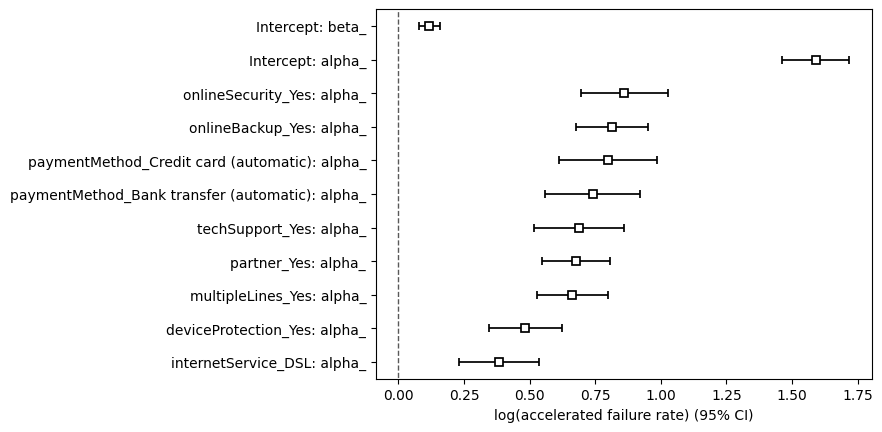

In [74]:
aft.plot()

In [75]:
# Fit the Kaplan-Meier model
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
 
T=telco_pd['tenure'] #duration
C=telco_pd['churn'].astype(float) #event observed
 
kmf.fit(T,C)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 3351 total observations, 1795 right-censored observations>

In [76]:
# Utility function for plotting
import matplotlib.pyplot as plt
 
def plot_km_logOdds(col):
  ax = plt.subplot(111)
  for r in telco_pd[col].unique():
    ix = telco_pd[col] == r
    kmf.fit(T[ix], C[ix],label=r)
    sf = kmf.survival_function_
    sf['failureOdds'] = (np.log(1-sf))/sf
    sf['logTime'] = np.log(sf.index)
    plt.plot(sf['logTime'],sf['failureOdds'])

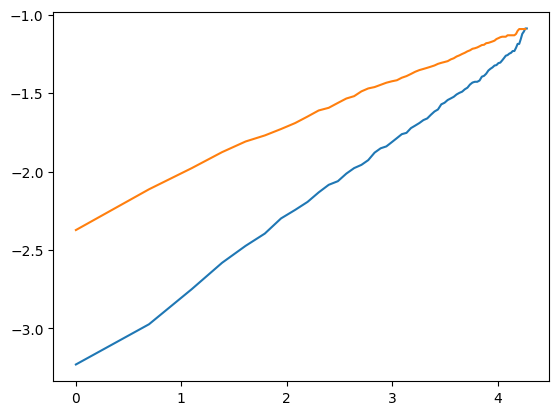

In [77]:
plot_km_logOdds('partner')

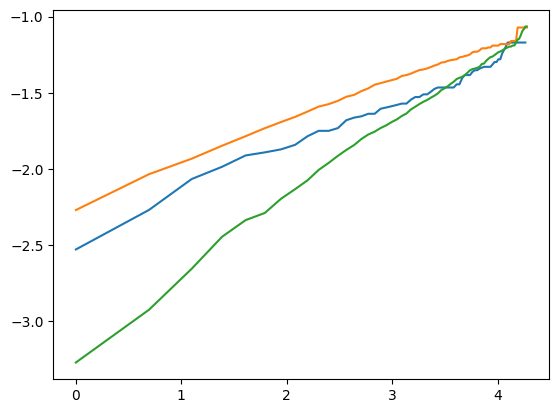

In [78]:
plot_km_logOdds('multipleLines')

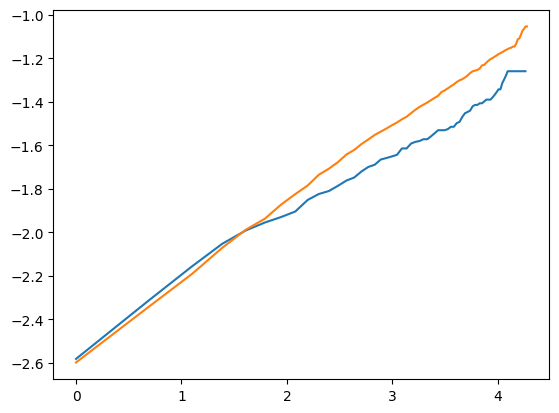

In [79]:
plot_km_logOdds('internetService')

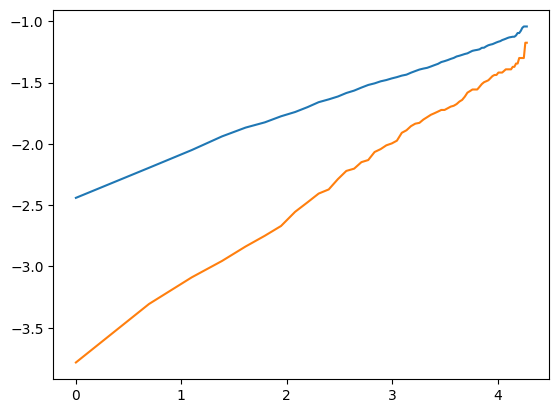

In [80]:
plot_km_logOdds('onlineSecurity')

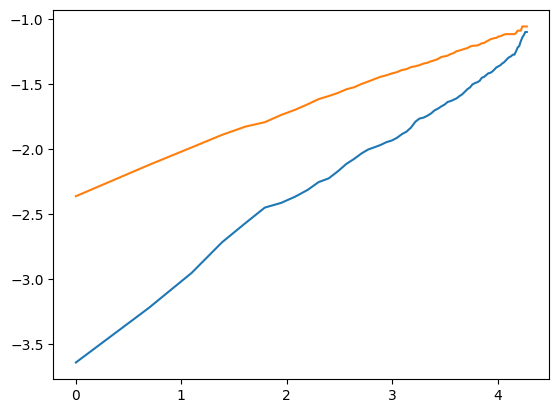

In [82]:
plot_km_logOdds('onlineBackup')

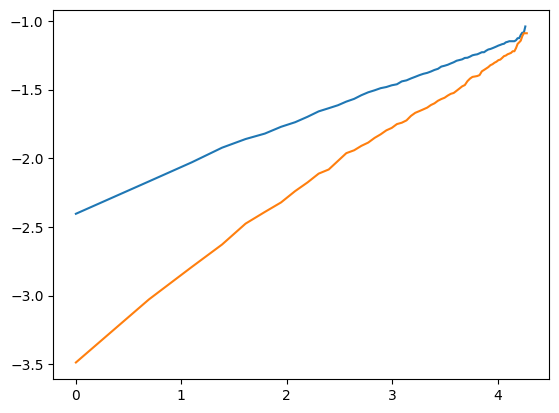

In [83]:
plot_km_logOdds('deviceProtection')

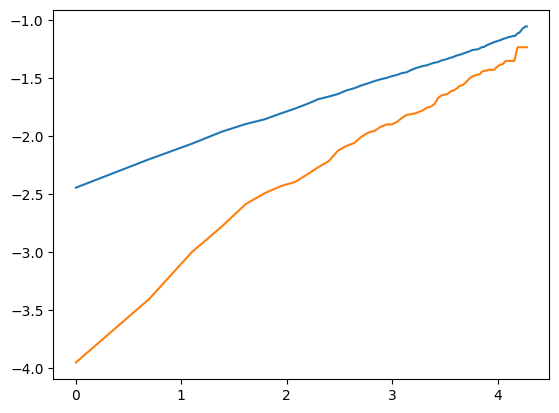

In [84]:
plot_km_logOdds('techSupport')

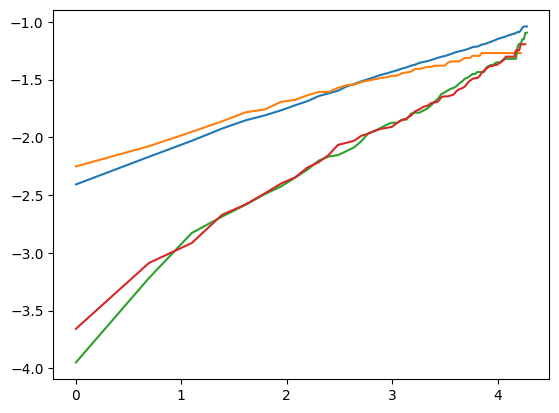

In [85]:
plot_km_logOdds('paymentMethod')

# 05_customer_lifetime_value

In [86]:
# Import libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
 
from lifelines import WeibullAFTFitter,LogNormalAFTFitter,LogLogisticAFTFitter
from lifelines.fitters.coxph_fitter import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

In [87]:
# Load the Telco silver table
telco_pd = spark.table('silver_monthly_customers').toPandas()

In [88]:
# Encode columns of interest
encode_cols = ['dependents','internetService','onlineBackup','techSupport','paperlessBilling']
 
encoded_pd = pd.get_dummies(telco_pd,
               columns=encode_cols,
               prefix=encode_cols,
               drop_first=False)
 
encoded_pd.head()

,customerID,gender,seniorCitizen,partner,tenure,phoneService,multipleLines,onlineSecurity,deviceProtection,streamingTV,...,dependents_No,dependents_Yes,internetService_DSL,internetService_Fiber optic,onlineBackup_No,onlineBackup_Yes,techSupport_No,techSupport_Yes,paperlessBilling_No,paperlessBilling_Yes
0,7590-VHVEG,Female,0.0,Yes,1.0,No,No phone service,No,No,No,...,True,False,True,False,False,True,True,False,False,True
1,3668-QPYBK,Male,0.0,No,2.0,Yes,No,Yes,No,No,...,True,False,True,False,False,True,True,False,False,True
2,9237-HQITU,Female,0.0,No,2.0,Yes,No,No,No,No,...,True,False,False,True,True,False,True,False,False,True
3,9305-CDSKC,Female,0.0,No,8.0,Yes,Yes,No,Yes,Yes,...,True,False,False,True,True,False,True,False,False,True
4,1452-KIOVK,Male,0.0,No,22.0,Yes,Yes,No,No,Yes,...,False,True,False,True,False,True,True,False,False,True


In [89]:
# Create new dataframe consisting of only the variables needed to fit the model
survival_pd = encoded_pd[['churn','tenure','dependents_Yes','internetService_DSL','onlineBackup_Yes','techSupport_Yes']]

In [90]:
# Cast churn column as a float
survival_pd.loc[:,'churn'] = survival_pd.loc[:,'churn'].astype('float')

In [91]:
cph = CoxPHFitter(alpha=0.05)
cph.fit(survival_pd, 'tenure', 'churn')

<lifelines.CoxPHFitter: fitted with 3351 total observations, 1795 right-censored observations>

In [93]:
# Create widgets
cols = ['dependents_Yes','internetService_DSL','onlineBackup_Yes','techSupport_Yes','partner_Yes',' internal rate of return']
 
# dbutils.widgets.removeAll()
 
# for col in cols:
#   if col == ' internal rate of return':
#     dbutils.widgets.text(' internal rate of return',defaultValue='0.10')
#   else:
#     dbutils.widgets.dropdown(col,choices=['0','1'],defaultValue='0')

In [98]:
# Construct dataframe with values from widgets
def get_widget_values():
  widget_dict = {col:dbutils.widgets.get(col) for col in cols}
  return pd.DataFrame.from_dict(widget_dict,orient='index').T
 
def get_payback_df():
  df = get_widget_values()
  irr = df[' internal rate of return'].astype('float64')[0]/12
  cohort_df = pd.concat([pd.DataFrame([1.00]),round(cph.predict_survival_function(df),2)]).rename(columns={0:'Survival Probability'})
  cohort_df['Contract Month'] = cohort_df.index.astype('int')
  cohort_df['Monthly Profit for the Selected Plan'] = 30
  cohort_df['Avg Expected Monthly Profit'] = round(cohort_df['Survival Probability'] * cohort_df['Monthly Profit for the Selected Plan'],2)
  cohort_df['NPV of Avg Expected Monthly Profit'] = round(cohort_df['Avg Expected Monthly Profit'] / ((1+irr)**cohort_df['Contract Month']),2)
  cohort_df['Cumulative NPV'] = cohort_df['NPV of Avg Expected Monthly Profit'].cumsum()
  cohort_df['Contract Month'] = cohort_df['Contract Month'] + 1
  return cohort_df[['Contract Month','Survival Probability','Monthly Profit for the Selected Plan','Avg Expected Monthly Profit','NPV of Avg Expected Monthly Profit','Cumulative NPV']].set_index('Contract Month')

In [99]:
pd.options.display.max_rows = 25
get_payback_df()[0:25]

TypeError: unhashable type: 'list'

In [100]:
import seaborn as sns
ax = sns.barplot(['12 Months','24 Months','36 Months'],get_payback_df().iloc[[11,23,35],:]['Cumulative NPV'])

TypeError: unhashable type: 'list'

In [101]:
sns.lineplot(get_payback_df().index,get_payback_df()['Survival Probability'])

TypeError: unhashable type: 'list'

# 06_conclusion_and_references